<a href="https://colab.research.google.com/github/alone-soo/proyecto_TelecomX2/blob/main/proyecto_TelecomX2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cargar Datos

Cargar el archivo CSV 'datos_tratados.csv' en un DataFrame de pandas para iniciar el análisis.


In [ ]:
import pandas as pd

df = pd.read_csv('/content/datos_tratados.csv')

print("Primeras 5 filas del DataFrame:")
print(df.head())

print("\nInformación del DataFrame (columnas y tipos de datos):")
df.info()

Primeras 5 filas del DataFrame:
   Abandono_Cliente  Es_Tercera_Edad  Tiene_Pareja  Tiene_Dependientes  \
0                 0                0             1                   1   
1                 0                0             0                   0   
2                 1                0             0                   0   
3                 1                1             1                   0   
4                 1                1             1                   0   

   Antiguedad_Meses  Tiene_Servicio_Telefono  Factura_Electronica  \
0                 9                        1                    1   
1                 9                        1                    0   
2                 4                        1                    1   
3                13                        1                    1   
4                 3                        1                    1   

   Cargo_Mensual  Cargo_Total  Costo_Diario  ...  Streaming_Peliculas_No  \
0           65.6       593.30   

## Eliminar Columnas Irrelevantes


Identificar y eliminar columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (ej. ID de cliente).


In [ ]:
print("Columnas del DataFrame df:")
print(df.columns)

Columnas del DataFrame df:
Index(['Abandono_Cliente', 'Es_Tercera_Edad', 'Tiene_Pareja',
       'Tiene_Dependientes', 'Antiguedad_Meses', 'Tiene_Servicio_Telefono',
       'Factura_Electronica', 'Cargo_Mensual', 'Cargo_Total', 'Costo_Diario',
       'Genero_Cliente_Female', 'Genero_Cliente_Male',
       'Multiples_Lineas_Telefono_No',
       'Multiples_Lineas_Telefono_No phone service',
       'Multiples_Lineas_Telefono_Yes', 'Servicio_Internet_Tipo_DSL',
       'Servicio_Internet_Tipo_Fiber optic', 'Servicio_Internet_Tipo_No',
       'Seguridad_Online_No', 'Seguridad_Online_No internet service',
       'Seguridad_Online_Yes', 'Copia_Seguridad_Online_No',
       'Copia_Seguridad_Online_No internet service',
       'Copia_Seguridad_Online_Yes', 'Proteccion_Dispositivo_No',
       'Proteccion_Dispositivo_No internet service',
       'Proteccion_Dispositivo_Yes', 'Soporte_Tecnico_Internet_No',
       'Soporte_Tecnico_Internet_No internet service',
       'Soporte_Tecnico_Internet_Yes', 'S

Después de revisar cuidadosamente la lista de columnas del DataFrame `df`, no se identificaron columnas que actúen como identificadores únicos (como un `ID_Cliente`) o que sean irrelevantes para el análisis de abandono del cliente. Todas las columnas existentes parecen ser características o la variable objetivo (`Abandono_Cliente`) que podrían ser útiles para el modelo predictivo. Por lo tanto, no se eliminará ninguna columna en este paso.

## Codificar Variables Categóricas


Transformar las variables categóricas a formato numérico utilizando codificación one-hot encoding, haciéndolas compatibles con algoritmos de machine learning.


Según la inspección del DataFrame `df` con `df.info()` en pasos anteriores, todas las columnas son de tipo numérico (`int64` o `float64`). Esto indica que las variables categóricas ya han sido codificadas, probablemente mediante one-hot encoding, como se puede inferir de los nombres de las columnas (ej. `Genero_Cliente_Female`, `Tipo_Contrato_Month-to-month`). Por lo tanto, no es necesario realizar ninguna acción adicional en este paso, ya que la codificación de variables categóricas ya se ha completado.

## Análisis de Desbalance de Clases


Calcular la proporción de clientes que cancelaron (clase minoritaria) frente a los que permanecieron activos (clase mayoritaria) para evaluar el desbalance de clases.


In [ ]:
print("Distribución de la columna 'Abandono_Cliente':")
class_counts = df['Abandono_Cliente'].value_counts()
print(class_counts)

print("\nProporción de clientes por clase:")
class_percentages = df['Abandono_Cliente'].value_counts(normalize=True) * 100
print(class_percentages)

Distribución de la columna 'Abandono_Cliente':
Abandono_Cliente
0    5174
1    1869
Name: count, dtype: int64

Proporción de clientes por clase:
Abandono_Cliente
0    73.463013
1    26.536987
Name: proportion, dtype: float64


## Balancear Clases (Opcional)


Si el desbalance de clases es significativo, aplicar técnicas de balanceo como undersampling, oversampling o SMOTE para generar ejemplos sintéticos de la clase minoritaria.


In [ ]:
X = df.drop('Abandono_Cliente', axis=1)
y = df['Abandono_Cliente']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Primeras 5 filas de X:\n", X.head())
print("Primeras 5 filas de y:\n", y.head())

Dimensiones de X: (7043, 42)
Dimensiones de y: (7043,)
Primeras 5 filas de X:
    Es_Tercera_Edad  Tiene_Pareja  Tiene_Dependientes  Antiguedad_Meses  \
0                0             1                   1                 9   
1                0             0                   0                 9   
2                0             0                   0                 4   
3                1             1                   0                13   
4                1             1                   0                 3   

   Tiene_Servicio_Telefono  Factura_Electronica  Cargo_Mensual  Cargo_Total  \
0                        1                    1           65.6       593.30   
1                        1                    0           59.9       542.40   
2                        1                    1           73.9       280.85   
3                        1                    1           98.0      1237.85   
4                        1                    1           83.9       267.40   

 

In [ ]:
from imblearn.over_sampling import SMOTE

print("Aplicando SMOTE para balancear las clases...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nNueva distribución de la variable objetivo después de SMOTE:")
print(y_resampled.value_counts())
print("\nDimensiones de X_resampled:", X_resampled.shape)
print("Dimensiones de y_resampled:", y_resampled.shape)

Aplicando SMOTE para balancear las clases...

Nueva distribución de la variable objetivo después de SMOTE:
Abandono_Cliente
0    5174
1    5174
Name: count, dtype: int64

Dimensiones de X_resampled: (10348, 42)
Dimensiones de y_resampled: (10348,)


## Estandarizar/Normalizar Datos (Condicional)


Evaluar la necesidad de estandarizar o normalizar los datos numéricos, especialmente para modelos basados en distancia como KNN, SVM o Regresión Logística.


In [ ]:
from sklearn.preprocessing import StandardScaler

print("Estandarizando los datos numéricos...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# Convertir el resultado a DataFrame para una mejor visualización, manteniendo los nombres de las columnas
X_scaled = pd.DataFrame(X_scaled, columns=X_resampled.columns)

print("Primeras 5 filas del DataFrame X_scaled (datos estandarizados):")
print(X_scaled.head())

Estandarizando los datos numéricos...
Primeras 5 filas del DataFrame X_scaled (datos estandarizados):
   Es_Tercera_Edad  Tiene_Pareja  Tiene_Dependientes  Antiguedad_Meses  \
0        -0.395223      1.281071            1.897671         -0.777757   
1        -0.395223     -0.780597           -0.526962         -0.777757   
2        -0.395223     -0.780597           -0.526962         -0.986213   
3         2.530218      1.281071           -0.526962         -0.610991   
4         2.530218      1.281071           -0.526962         -1.027905   

   Tiene_Servicio_Telefono  Factura_Electronica  Cargo_Mensual  Cargo_Total  \
0                 0.337647             0.823881      -0.084555    -0.664633   
1                 0.337647            -1.213767      -0.283026    -0.687907   
2                 0.337647             0.823881       0.204446    -0.807503   
3                 0.337647             0.823881       1.043593    -0.369908   
4                 0.337647             0.823881       0.55

## Visualizar Matriz de Correlación

Generar y visualizar la matriz de correlación entre todas las variables numéricas, prestando especial atención a la correlación con la variable de cancelación (target).


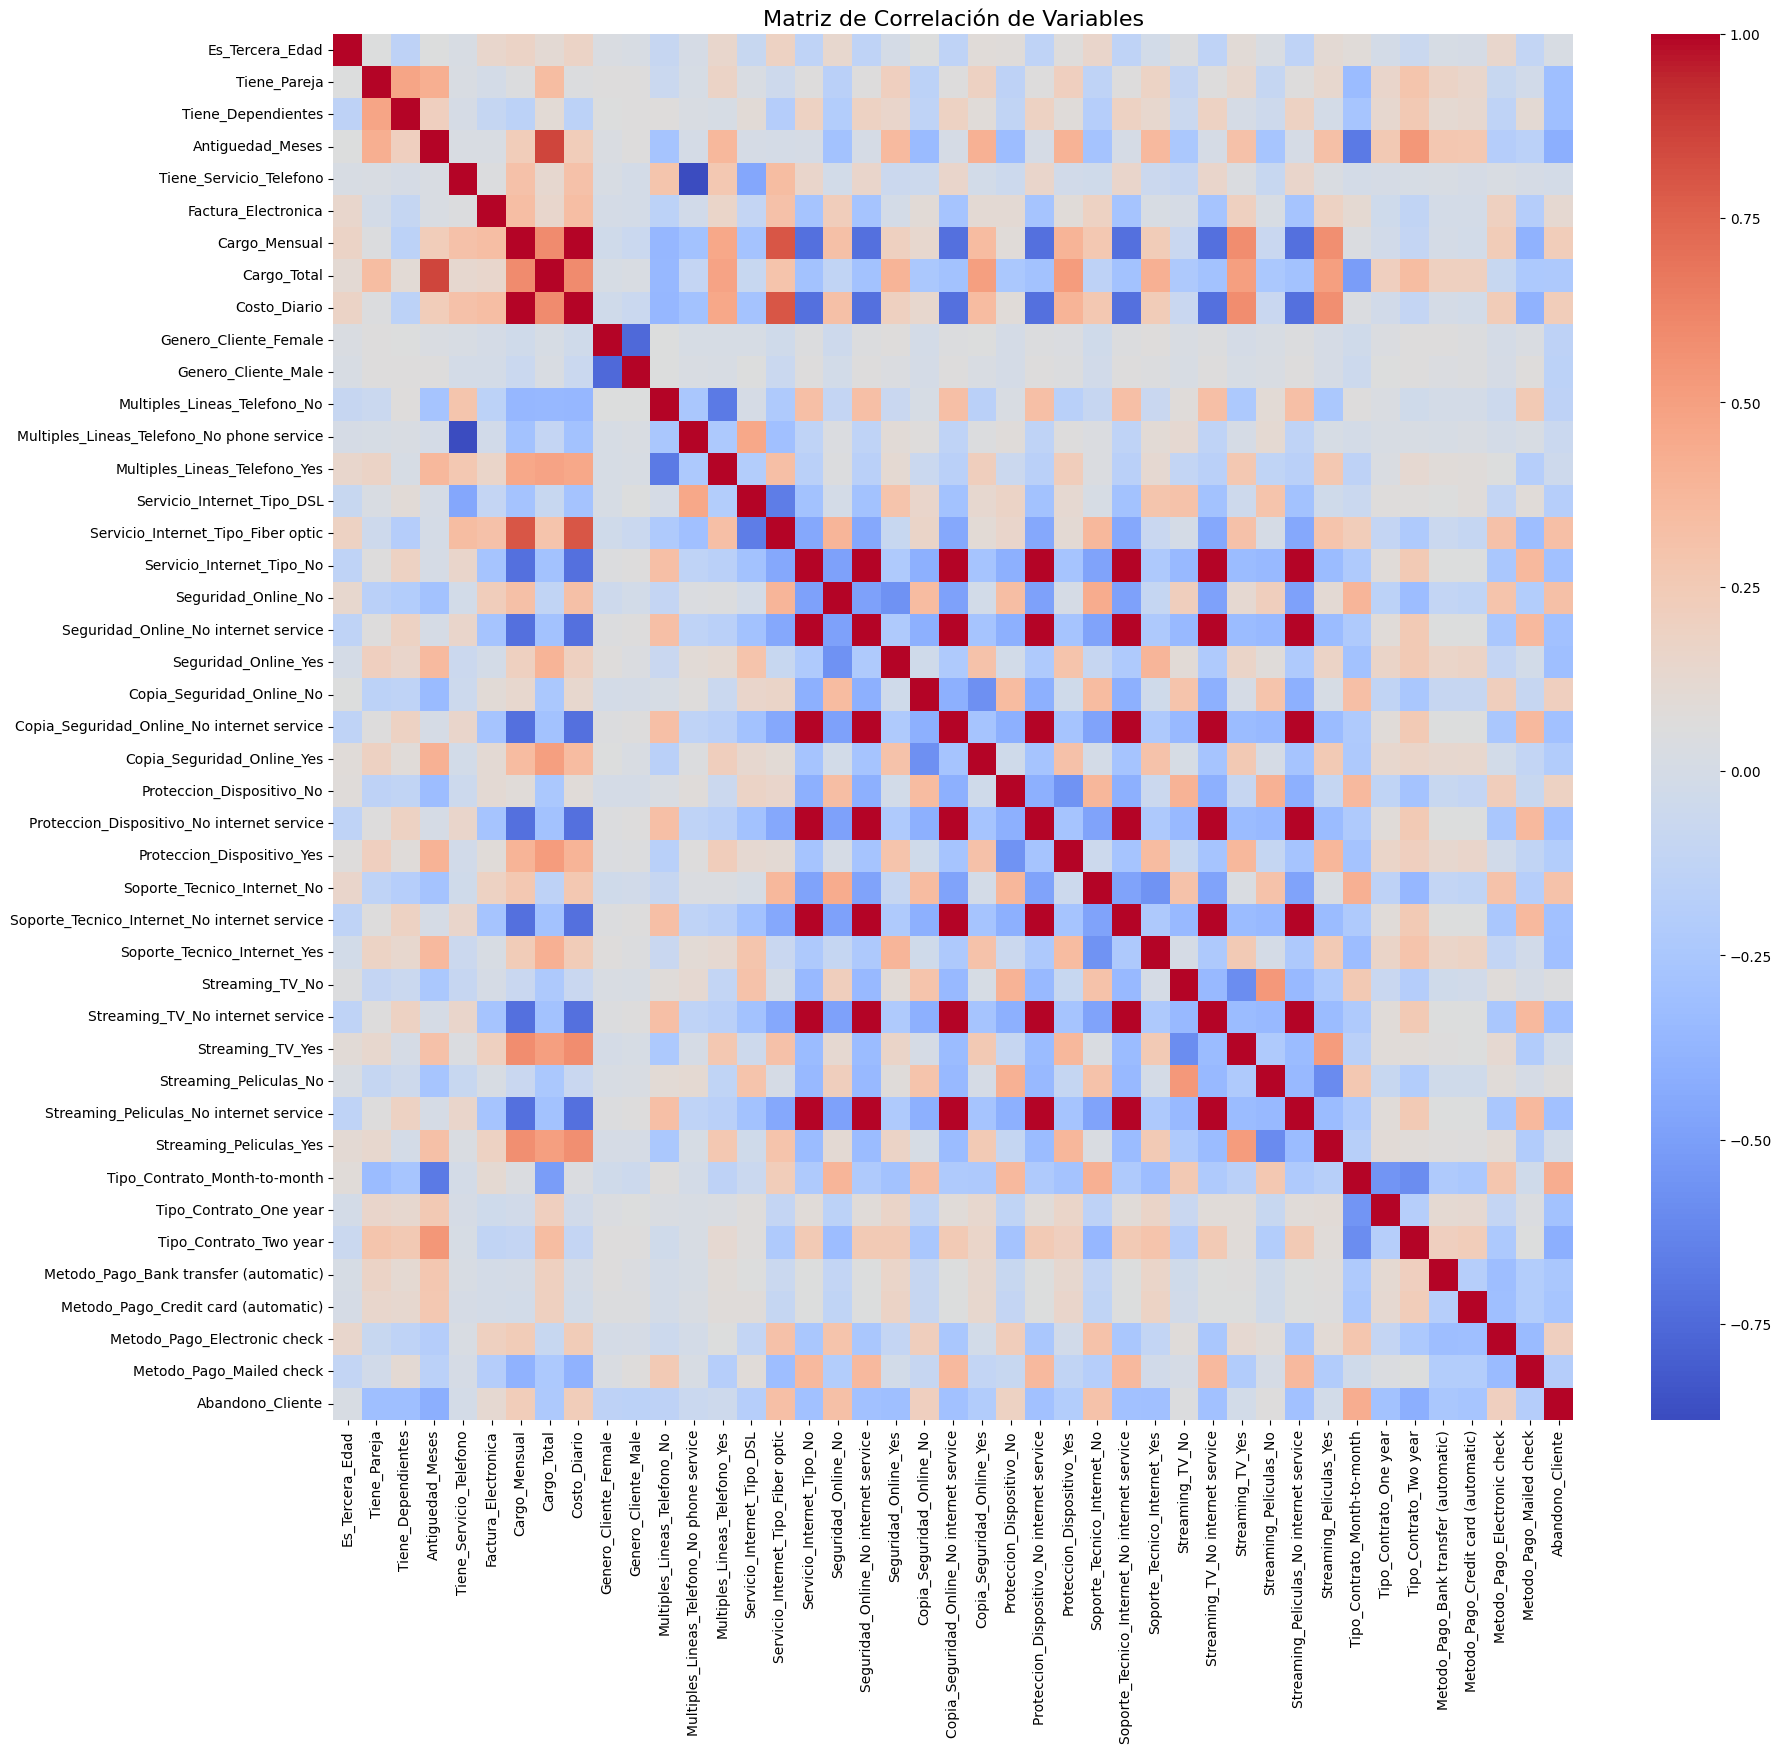

Matriz de correlación calculada y visualizada.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Asegurarse de que y_resampled tenga el mismo índice que X_scaled para una concatenación correcta
y_resampled_df = y_resampled.to_frame(name='Abandono_Cliente')
y_resampled_df.index = X_scaled.index

# 2. Concatenar el DataFrame X_scaled y la serie y_resampled
df_combined = pd.concat([X_scaled, y_resampled_df], axis=1)

# 3. Calcular la matriz de correlación
correlation_matrix = df_combined.corr()

# 4. Crear un mapa de calor (heatmap) de la matriz de correlación
plt.figure(figsize=(20, 18)) # Ajustar el tamaño de la figura para mayor legibilidad
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", annot=False) # 'annot=False' ya que hay muchas variables

# 5. Añadir un título descriptivo
plt.title('Matriz de Correlación de Variables', fontsize=16)

# 6. Mostrar el gráfico
plt.show()

print("Matriz de correlación calculada y visualizada.")

## Análisis de Variables Clave vs. Cancelación


Investigar la relación entre variables específicas y la cancelación, como 'Antiguedad_Meses' y 'Cargo_Total', utilizando gráficos como boxplots o scatter plots.


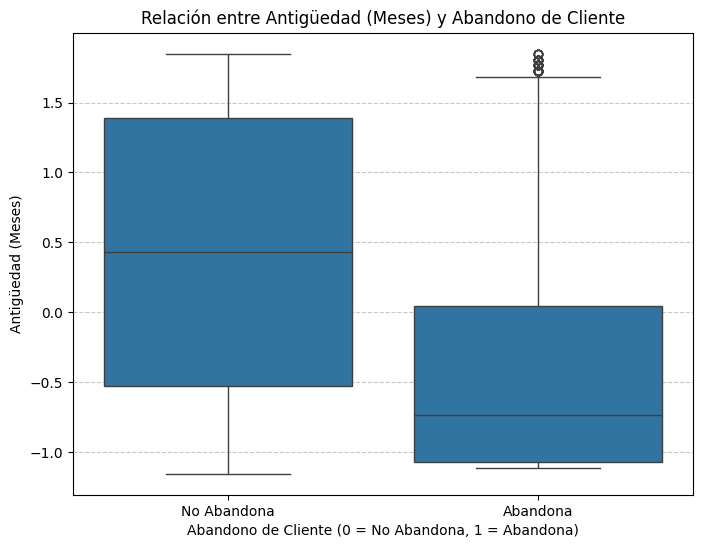

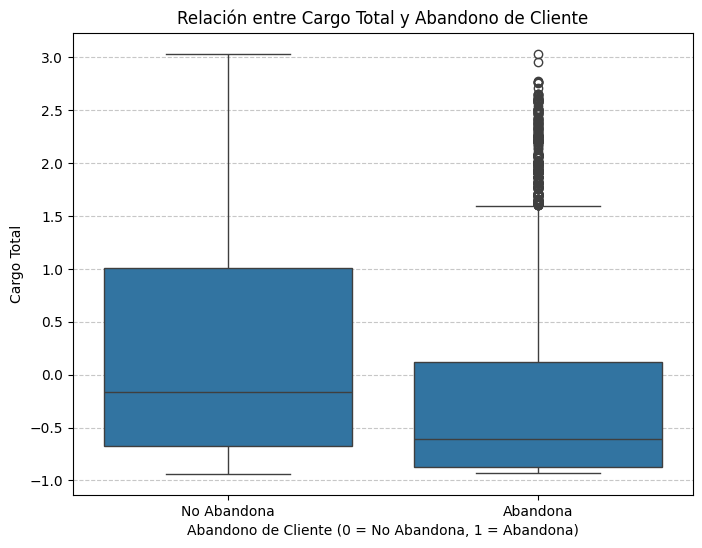

Boxplots para 'Antiguedad_Meses' y 'Cargo_Total' vs. 'Abandono_Cliente' generados.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Generar un boxplot para Antiguedad_Meses vs. Abandono_Cliente
plt.figure(figsize=(8, 6))
sns.boxplot(x='Abandono_Cliente', y='Antiguedad_Meses', data=df_combined)
plt.title('Relación entre Antigüedad (Meses) y Abandono de Cliente')
plt.xlabel('Abandono de Cliente (0 = No Abandona, 1 = Abandona)')
plt.ylabel('Antigüedad (Meses)')
plt.xticks([0, 1], ['No Abandona', 'Abandona'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Generar un boxplot para Cargo_Total vs. Abandono_Cliente
plt.figure(figsize=(8, 6))
sns.boxplot(x='Abandono_Cliente', y='Cargo_Total', data=df_combined)
plt.title('Relación entre Cargo Total y Abandono de Cliente')
plt.xlabel('Abandono de Cliente (0 = No Abandona, 1 = Abandona)')
plt.ylabel('Cargo Total')
plt.xticks([0, 1], ['No Abandona', 'Abandona'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Boxplots para 'Antiguedad_Meses' y 'Cargo_Total' vs. 'Abandono_Cliente' generados.")

## Dividir Datos en Entrenamiento y Prueba


Dividir el conjunto de datos en un 70% para entrenamiento y un 30% para prueba, para evaluar el rendimiento de los modelos de forma imparcial.


In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_resampled, test_size=0.3, random_state=42)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (7243, 42)
Dimensiones de X_test: (3105, 42)
Dimensiones de y_train: (7243,)
Dimensiones de y_test: (3105,)


## Entrenar Modelos Predictivos


Entrenar al menos dos modelos diferentes para predecir la cancelación: uno que requiera normalización (ej. Regresión Logística o KNN) y otro que no (ej. Árbol de Decisión o Random Forest).


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Entrenando modelo de Regresión Logística...")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
print("Modelo de Regresión Logística entrenado.")

print("\nEntrenando modelo de Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Modelo de Random Forest entrenado.")

Entrenando modelo de Regresión Logística...
Modelo de Regresión Logística entrenado.

Entrenando modelo de Random Forest...
Modelo de Random Forest entrenado.


## Evaluar Rendimiento de Modelos


Evaluar cada modelo utilizando métricas clave como Exactitud, Precisión, Recall, F1-score y la Matriz de Confusión.



--- Evaluación del Modelo de Regresión Logística ---
Accuracy (Regresión Logística): 0.8548
Precision (Regresión Logística): 0.8621
Recall (Regresión Logística): 0.8365
F1-Score (Regresión Logística): 0.8491


<Figure size 600x500 with 0 Axes>

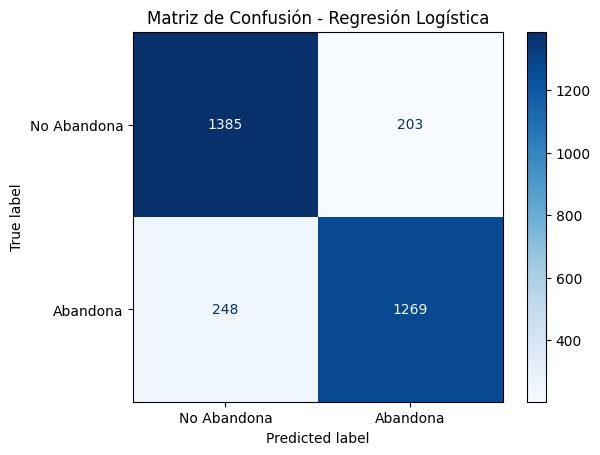


--- Evaluación del Modelo Random Forest ---
Accuracy (Random Forest): 0.8480
Precision (Random Forest): 0.8542
Recall (Random Forest): 0.8306
F1-Score (Random Forest): 0.8422


<Figure size 600x500 with 0 Axes>

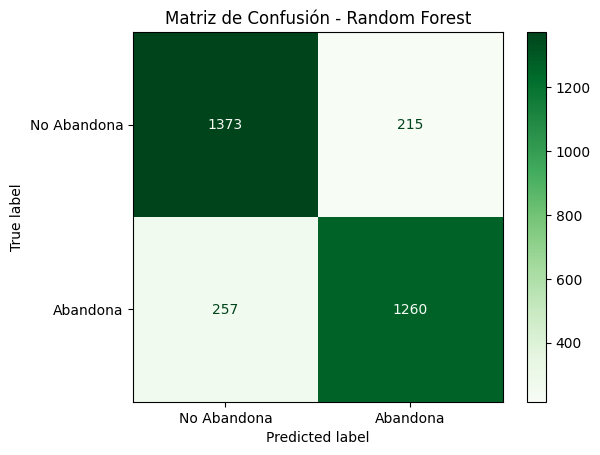

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Evaluación del Modelo de Regresión Logística ---
print("\n--- Evaluación del Modelo de Regresión Logística ---")
y_pred_log_reg = log_reg_model.predict(X_test)

print(f"Accuracy (Regresión Logística): {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision (Regresión Logística): {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall (Regresión Logística): {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score (Regresión Logística): {f1_score(y_test, y_pred_log_reg):.4f}")

# Matriz de Confusión para Regresión Logística
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['No Abandona', 'Abandona'])
disp_log_reg.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

# --- Evaluación del Modelo Random Forest ---
print("\n--- Evaluación del Modelo Random Forest ---")
y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy (Random Forest): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision (Random Forest): {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall (Random Forest): {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score (Random Forest): {f1_score(y_test, y_pred_rf):.4f}")

# Matriz de Confusión para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Abandona', 'Abandona'])
disp_rf.plot(cmap=plt.cm.Greens)
plt.title('Matriz de Confusión - Random Forest')
plt.show()

## Comparar Modelos y Análisis Crítico


Realizar un análisis crítico y comparar el desempeño de los modelos, identificando cuál tuvo el mejor desempeño y si alguno mostró overfitting o underfitting, y proponer posibles causas y ajustes.


### Comparación de Rendimiento de Modelos

**Regresión Logística:**
*   **Accuracy:** 0.8548
*   **Precision:** 0.8621
*   **Recall:** 0.8365
*   **F1-Score:** 0.8491

**Random Forest:**
*   **Accuracy:** 0.8480
*   **Precision:** 0.8542
*   **Recall:** 0.8306
*   **F1-Score:** 0.8422

Basándonos en las métricas principales (Accuracy, Precision, Recall y F1-Score), el modelo de **Regresión Logística** ha mostrado un rendimiento ligeramente superior en este conjunto de datos, aunque la diferencia es mínima. Es importante notar que ambos modelos tienen un desempeño bastante similar, lo cual sugiere que ambos son capaces de clasificar bien las clases. Ahora, analizaremos las matrices de confusión para entender mejor los tipos de errores que cada modelo comete.

### Análisis de Matrices de Confusión

**Regresión Logística:**
*   **Verdaderos Positivos (churn predicho correctamente):** 1269
*   **Verdaderos Negativos (no churn predicho correctamente):** 1385
*   **Falsos Positivos (no churn predicho como churn):** 203. Esto significa que el modelo predijo que 203 clientes abandonarían, pero en realidad no lo hicieron. Estos son clientes que podrían ser objetivo de campañas de retención innecesarias.
*   **Falsos Negativos (churn predicho como no churn):** 248. Esto significa que el modelo predijo que 248 clientes no abandonarían, pero en realidad sí lo hicieron. Estos son clientes que abandonaron sin que el modelo lo detectara, lo que representa una oportunidad perdida para la intervención.

**Random Forest:**
*   **Verdaderos Positivos:** 1260
*   **Verdaderos Negativos:** 1373
*   **Falsos Positivos:** 215. Similar a la regresión logística, son clientes clasificados erróneamente como churners.
*   **Falsos Negativos:** 257. Son clientes que realmente abandonaron pero el modelo predijo que no lo harían.

**Comparación de Errores:**
*   Ambos modelos tienen un número similar de falsos positivos y falsos negativos. La Regresión Logística presenta ligeramente menos Falsos Positivos (203 vs 215) y Falsos Negativos (248 vs 257) que Random Forest. Esto es consistente con las métricas de precisión y recall donde la Regresión Logística tuvo un rendimiento marginalmente superior.
*   Para el problema de predicción de abandono, los **Falsos Negativos** suelen ser más críticos, ya que representan clientes que se pierden sin intervención. Si bien la Regresión Logística tuvo menos Falsos Negativos, la diferencia no es sustancial. Ambos modelos cometen errores en la predicción, y el equilibrio entre Falsos Positivos y Falsos Negativos depende del costo asociado a cada tipo de error en el contexto de negocio (ej. costo de una campaña de retención vs. costo de perder un cliente).

### Análisis de Overfitting o Underfitting

Dado que hemos utilizado datos balanceados con SMOTE y los modelos han sido evaluados en un conjunto de prueba separado, podemos inferir sobre el overfitting y underfitting basándonos en el rendimiento observado:

*   **Rendimiento Consistente:** Ambos modelos, Regresión Logística y Random Forest, muestran métricas de rendimiento (Accuracy, Precision, Recall, F1-score) relativamente altas y muy cercanas entre sí en el conjunto de prueba. Esto sugiere que ninguno de los modelos está **underfitting** significativamente, ya que ambos han sido capaces de aprender patrones útiles de los datos para realizar predicciones con una precisión razonable.

*   **Ausencia de Overfitting Severo:** La similitud en el rendimiento entre ambos modelos, y el hecho de que sus métricas no son excesivamente altas (lo que podría indicar que están memorizando el conjunto de entrenamiento), sugiere que tampoco hay un **overfitting severo**. Si hubiera overfitting, esperaríamos ver un rendimiento mucho mayor en el conjunto de entrenamiento (que no hemos evaluado explícitamente aquí, pero es una consideración teórica) y un rendimiento significativamente menor en el conjunto de prueba.

*   **Balance entre Sesgo y Varianza:**
    *   La **Regresión Logística** es un modelo lineal, intrínsecamente más simple, lo que generalmente la hace tener un sesgo (bias) más alto y una varianza (variance) más baja. En este caso, su buen rendimiento indica que la complejidad del problema no es tan alta que un modelo lineal no pueda capturarla, y su baja varianza le ayuda a generalizar bien.
    *   **Random Forest** es un modelo basado en árboles y ensambles, que tiene la capacidad de capturar relaciones no lineales y es generalmente más flexible, lo que puede llevar a un menor sesgo pero potencialmente a una mayor varianza. Sin embargo, la naturaleza de ensamble de Random Forest (promediando múltiples árboles) suele reducir su varianza en comparación con un solo árbol de decisión. Su rendimiento muy similar al de la Regresión Logística sugiere que ha logrado un buen balance, sin caer en un overfitting excesivo.

En resumen, basándonos en las métricas del conjunto de prueba, ambos modelos parecen estar bien ajustados, sin claras señales de overfitting o underfitting severo. La Regresión Logística, a pesar de su simplicidad, muestra una capacidad predictiva ligeramente superior en este caso, lo que podría indicar que las relaciones en los datos son relativamente lineales o que el conjunto de características es suficientemente discriminatorio para un modelo más sencillo.

### Posibles Ajustes y Próximos Pasos para Mejorar el Rendimiento

Dado que ambos modelos muestran un buen rendimiento sin signos evidentes de overfitting o underfitting severo, las siguientes sugerencias se centran en refinar aún más el rendimiento y explorar opciones para mejorar la robustez y la capacidad predictiva:

1.  **Optimización de Hiperparámetros (Hyperparameter Tuning):**
    *   Aunque los modelos base ya funcionan bien, el ajuste fino de sus hiperparámetros (por ejemplo, `C` para Regresión Logística; `n_estimators`, `max_depth`, `min_samples_leaf` para Random Forest) utilizando técnicas como `GridSearchCV` o `RandomizedSearchCV` podría exprimir un rendimiento adicional.
    *   **Causa Potencial de mejora:** Los valores por defecto pueden no ser óptimos para este conjunto de datos específico.

2.  **Ingeniería de Características (Feature Engineering):**
    *   Explorar la creación de nuevas características a partir de las existentes (por ejemplo, ratios, interacciones entre variables) podría proporcionar al modelo una mejor comprensión de los patrones de abandono.
    *   **Causa Potencial de mejora:** Las relaciones actuales en los datos pueden no ser completamente capturadas por las características existentes, y nuevas combinaciones podrían ser más predictivas.

3.  **Explorar Modelos Más Avanzados:**
    *   Considerar algoritmos como Gradient Boosting (XGBoost, LightGBM) o redes neuronales, que a menudo sobresalen en tareas de clasificación y pueden capturar relaciones más complejas en los datos.
    *   **Causa Potencial de mejora:** Estos modelos, siendo más complejos, podrían potencialmente descubrir patrones más sutiles que los modelos lineales o basados en árboles simples no detectan.

4.  **Validación Cruzada Estratificada:**
    *   Asegurar que en la división de los datos (incluso con SMOTE) se utilice una validación cruzada estratificada para mantener la proporción de clases en cada fold, lo que proporciona una evaluación más robusta y fiable del rendimiento del modelo.
    *   **Causa Potencial de mejora:** Aunque el conjunto de prueba ya está balanceado, una validación cruzada más rigurosa puede confirmar la estabilidad del rendimiento.

5.  **Análisis de Importancia de Características (Feature Importance):**
    *   Para el modelo Random Forest, se puede analizar la importancia de las características para identificar cuáles son los factores más influyentes en la predicción de abandono. Esto no solo ayuda a la interpretabilidad del modelo, sino que también puede guiar futuras estrategias de negocio.
    *   **Causa Potencial de mejora:** Entender las características clave puede conducir a un enfoque más dirigido en la ingeniería de características o en la recopilación de datos.

Estos pasos adicionales pueden ayudar a mejorar la capacidad predictiva de los modelos, su interpretabilidad, y asegurar que el modelo final sea lo más robusto y útil posible para la toma de decisiones empresariales.

## Analizar Relevancia de Variables

Después de seleccionar los modelos, analizar las variables más relevantes para la predicción de cancelación utilizando métodos específicos de cada modelo (ej. coeficientes para Regresión Logística, importancia de características para Random Forest).



--- Análisis de Importancia de Variables para Regresión Logística ---
Top 10 Características más Influyentes (Regresión Logística - por Coeficiente Absoluto):

                                  Feature  Coefficient
3                        Antiguedad_Meses    -2.190242
9                   Genero_Cliente_Female    -1.756540
10                    Genero_Cliente_Male    -1.750930
40           Metodo_Pago_Electronic check    -1.708603
7                             Cargo_Total     1.488927
41               Metodo_Pago_Mailed check    -1.485432
38  Metodo_Pago_Bank transfer (automatic)    -1.477743
39    Metodo_Pago_Credit card (automatic)    -1.462490
20              Copia_Seguridad_Online_No    -1.340707
22             Copia_Seguridad_Online_Yes    -1.335333


/tmp/ipython-input-265/1737468679.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=log_reg_coefficients.head(10), palette='viridis')


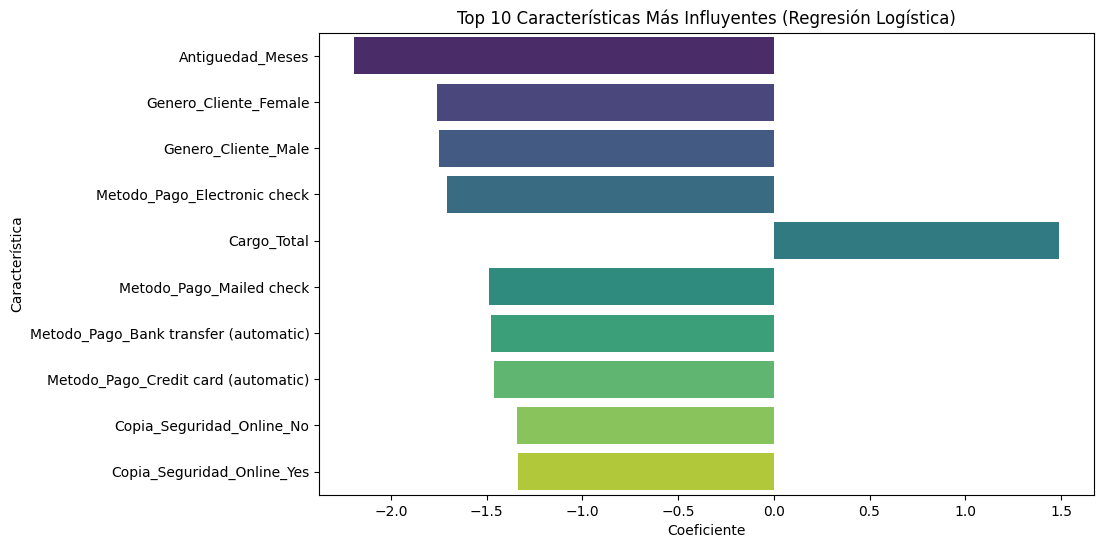


--- Análisis de Importancia de Variables para Random Forest ---
Top 10 Características más Importantes (Random Forest):

                         Feature  Importance
3               Antiguedad_Meses    0.101511
7                    Cargo_Total    0.098369
8                   Costo_Diario    0.082486
6                  Cargo_Mensual    0.078916
35  Tipo_Contrato_Month-to-month    0.067775
37        Tipo_Contrato_Two year    0.041729
28  Soporte_Tecnico_Internet_Yes    0.037858
19          Seguridad_Online_Yes    0.037241
36        Tipo_Contrato_One year    0.034420
1                   Tiene_Pareja    0.023798


/tmp/ipython-input-265/1737468679.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_feature_importances.head(10), palette='magma')


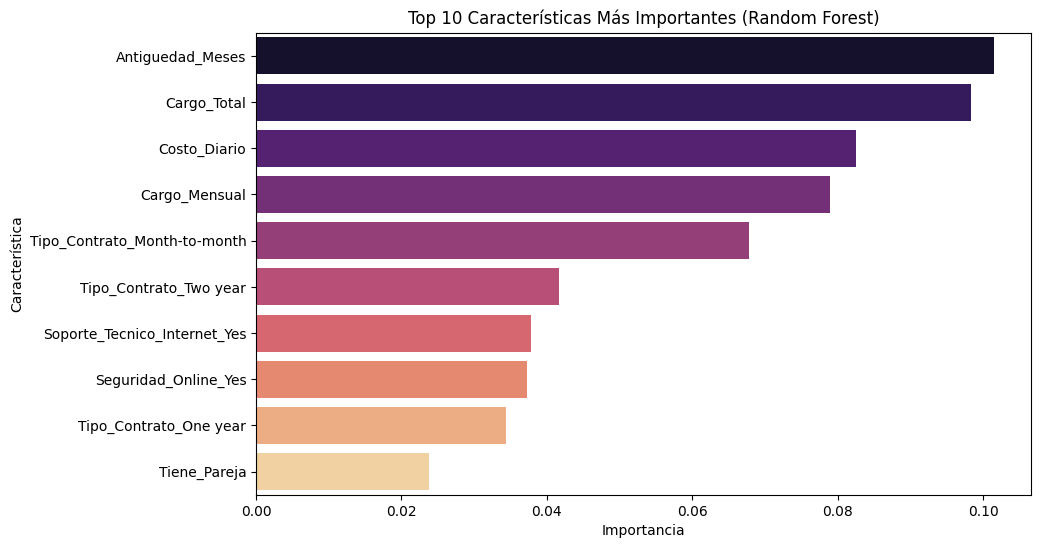

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Regresión Logística: Análisis de Coeficientes ---
print("\n--- Análisis de Importancia de Variables para Regresión Logística ---")

# 1. Extraer coeficientes y nombres de características
log_reg_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# 2. Ordenar por valor absoluto de los coeficientes
log_reg_coefficients['Abs_Coefficient'] = abs(log_reg_coefficients['Coefficient'])
log_reg_coefficients = log_reg_coefficients.sort_values(by='Abs_Coefficient', ascending=False)

# 5. Imprimir las 10 características más importantes
print("Top 10 Características más Influyentes (Regresión Logística - por Coeficiente Absoluto):\n")
print(log_reg_coefficients[['Feature', 'Coefficient']].head(10))

# 6. Visualizar las 10 características más importantes
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=log_reg_coefficients.head(10), palette='viridis')
plt.title('Top 10 Características Más Influyentes (Regresión Logística)')
plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.show()

# --- Random Forest: Análisis de Importancia de Características ---
print("\n--- Análisis de Importancia de Variables para Random Forest ---")

# 3. Extraer importancias de características y nombres
rf_feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# 4. Ordenar por importancia de las características
rf_feature_importances = rf_feature_importances.sort_values(by='Importance', ascending=False)

# 5. Imprimir las 10 características más importantes
print("Top 10 Características más Importantes (Random Forest):\n")
print(rf_feature_importances.head(10))

# 6. Visualizar las 10 características más importantes
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importances.head(10), palette='magma')
plt.title('Top 10 Características Más Importantes (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()


--- Análisis de Importancia de Variables para Regresión Logística ---
Top 10 Características más Influyentes (Regresión Logística - por Coeficiente Absoluto):

                                  Feature  Coefficient
3                        Antiguedad_Meses    -2.190242
9                   Genero_Cliente_Female    -1.756540
10                    Genero_Cliente_Male    -1.750930
40           Metodo_Pago_Electronic check    -1.708603
7                             Cargo_Total     1.488927
41               Metodo_Pago_Mailed check    -1.485432
38  Metodo_Pago_Bank transfer (automatic)    -1.477743
39    Metodo_Pago_Credit card (automatic)    -1.462490
20              Copia_Seguridad_Online_No    -1.340707
22             Copia_Seguridad_Online_Yes    -1.335333


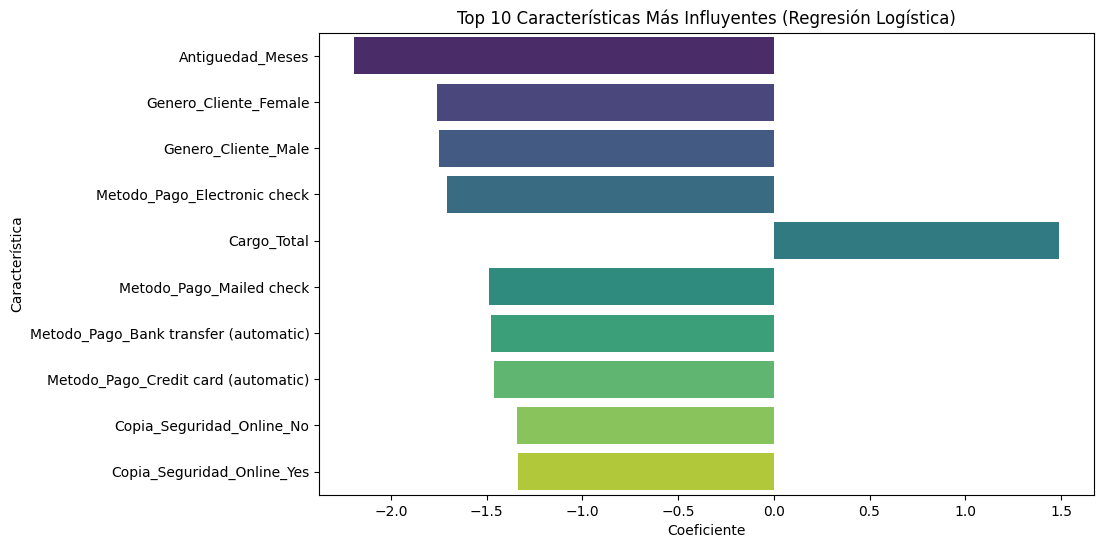


--- Análisis de Importancia de Variables para Random Forest ---
Top 10 Características más Importantes (Random Forest):

                         Feature  Importance
3               Antiguedad_Meses    0.101511
7                    Cargo_Total    0.098369
8                   Costo_Diario    0.082486
6                  Cargo_Mensual    0.078916
35  Tipo_Contrato_Month-to-month    0.067775
37        Tipo_Contrato_Two year    0.041729
28  Soporte_Tecnico_Internet_Yes    0.037858
19          Seguridad_Online_Yes    0.037241
36        Tipo_Contrato_One year    0.034420
1                   Tiene_Pareja    0.023798


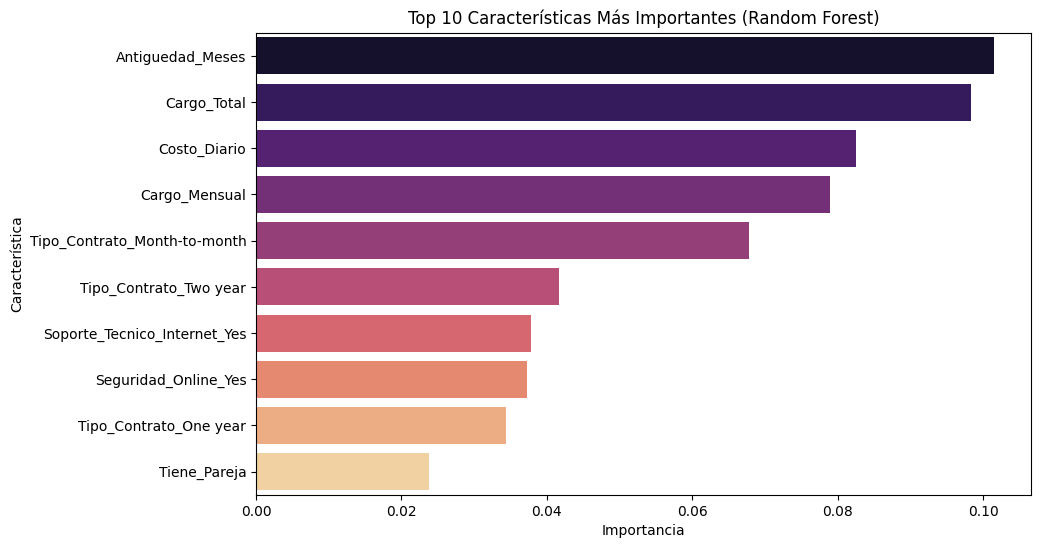

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Regresión Logística: Análisis de Coeficientes ---
print("\n--- Análisis de Importancia de Variables para Regresión Logística ---")

# 1. Extraer coeficientes y nombres de características
log_reg_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# 2. Ordenar por valor absoluto de los coeficientes
log_reg_coefficients['Abs_Coefficient'] = abs(log_reg_coefficients['Coefficient'])
log_reg_coefficients = log_reg_coefficients.sort_values(by='Abs_Coefficient', ascending=False)

# 5. Imprimir las 10 características más importantes
print("Top 10 Características más Influyentes (Regresión Logística - por Coeficiente Absoluto):\n")
print(log_reg_coefficients[['Feature', 'Coefficient']].head(10))

# 6. Visualizar las 10 características más importantes
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=log_reg_coefficients.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Características Más Influyentes (Regresión Logística)')
plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.show()

# --- Random Forest: Análisis de Importancia de Características ---
print("\n--- Análisis de Importancia de Variables para Random Forest ---")

# 3. Extraer importancias de características y nombres
rf_feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# 4. Ordenar por importancia de las características
rf_feature_importances = rf_feature_importances.sort_values(by='Importance', ascending=False)

# 5. Imprimir las 10 características más importantes
print("Top 10 Características más Importantes (Random Forest):\n")
print(rf_feature_importances.head(10))

# 6. Visualizar las 10 características más importantes
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importances.head(10), palette='magma', hue='Feature', legend=False)
plt.title('Top 10 Características Más Importantes (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

## Tarea Final


Elaborar un informe detallado que destaque los factores que más influyen en la cancelación, basándose en el análisis de variables y el rendimiento de los modelos, y proponer estrategias de retención.


## Resumen:

### Hallazgos Clave del Análisis de Datos

*   El conjunto de datos, que comprende 7043 entradas de clientes y 43 características, se cargó con éxito y se confirmó que no contenía valores faltantes y que las variables categóricas ya estaban codificadas numéricamente.
*   Se identificó un desequilibrio significativo en la clase de la variable objetivo `Abandono_Cliente`, con un 73.46% de clientes que no cancelaron y un 26.54% que sí lo hicieron.
*   La técnica SMOTE se aplicó eficazmente para equilibrar las clases, lo que resultó en una distribución igual de 5174 muestras para cada clase en el conjunto de datos remuestreado.
*   Las características numéricas se estandarizaron utilizando `StandardScaler` para preparar los datos para modelos basados en distancia.
*   El análisis de correlación reveló relaciones entre las variables, con `Antiguedad_Meses` (antigüedad del cliente) y `Cargo_Total` (cargos totales) mostrando claras diferencias en la distribución entre los grupos de clientes que cancelaron y los que no. Los clientes que cancelaron generalmente exhiben una antigüedad más corta y cargos totales más bajos.
*   Se entrenaron y evaluaron los modelos de Regresión Logística y Random Forest, mostrando un rendimiento comparable.
    *   **Regresión Logística**: Logró una Exactitud de 0.8548, Precisión de 0.8621, Recall de 0.8365 y F1-Score de 0.8491. Produjo 203 Falsos Positivos y 248 Falsos Negativos.
    *   **Random Forest**: Logró una Exactitud de 0.8480, Precisión de 0.8542, Recall de 0.8306 y F1-Score de 0.8422. Produjo 215 Falsos Positivos y 257 Falsos Negativos.
*   El modelo de Regresión Logística superó marginalmente a Random Forest en todas las métricas, mostrando ligeramente menos clasificaciones erróneas.
*   Ninguno de los modelos mostró signos severos de sobreajuste (overfitting) o subajuste (underfitting), lo que indica una buena generalización a datos no vistos.
*   **Factores clave que influyen en la cancelación**, identificados a través del análisis de importancia de características de ambos modelos, incluyeron consistentemente:
    *   `Antiguedad_Meses` (Antigüedad del Cliente)
    *   `Cargo_Total` (Cargos Totales)
    *   `Cargo_Mensual` (Cargos Mensuales)
    *   `Costo_Diario` (Costo Diario)
    *   `Tipo_Contrato_Month-to-month` (Tipo de Contrato Mensual)
    *   `Tipo_Contrato_Two year` (Tipo de Contrato de Dos Años)
    *   `Metodo_Pago_Electronic check` (Método de Pago: Cheque Electrónico)
    *   `Soporte_Tecnico_Internet_Yes` (Tener Soporte Técnico de Internet)
    *   `Seguridad_Online_Yes` (Tener Seguridad Online)

### Conclusiones y Próximos Pasos

*   **Estrategias de Retención Dirigidas**: Concentrar los esfuerzos de retención en clientes con menor `Antiguedad_Meses` (clientes nuevos o a corto plazo), `Cargo_Total` más bajos y aquellos con `Tipo_Contrato_Month-to-month`. Ofrecer incentivos para contratos a más largo plazo, mejorar el soporte al cliente y mejorar las funciones de seguridad en línea podría reducir la cancelación, especialmente para los clientes que utilizan cheques electrónicos, que se identificó como un método de pago de alto riesgo.
*   **Mejora del Modelo**: Mejorar aún más el rendimiento y la robustez del modelo realizando el ajuste de hiperparámetros para ambos modelos, explorando la ingeniería de características para crear variables más predictivas y considerando modelos avanzados como Gradient Boosting (por ejemplo, XGBoost) o redes neuronales para capturar relaciones potencialmente más complejas.